## Решение

<ipython-input-13-9e84fc55d1cd>:210: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X1, X2, Z1, levels=[0], colors='blue', linewidths=2, label='f1(x1,x2)=0')
<ipython-input-13-9e84fc55d1cd>:211: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X1, X2, Z2, levels=[0], colors='red', linewidths=2, label='f2(x1,x2)=0')


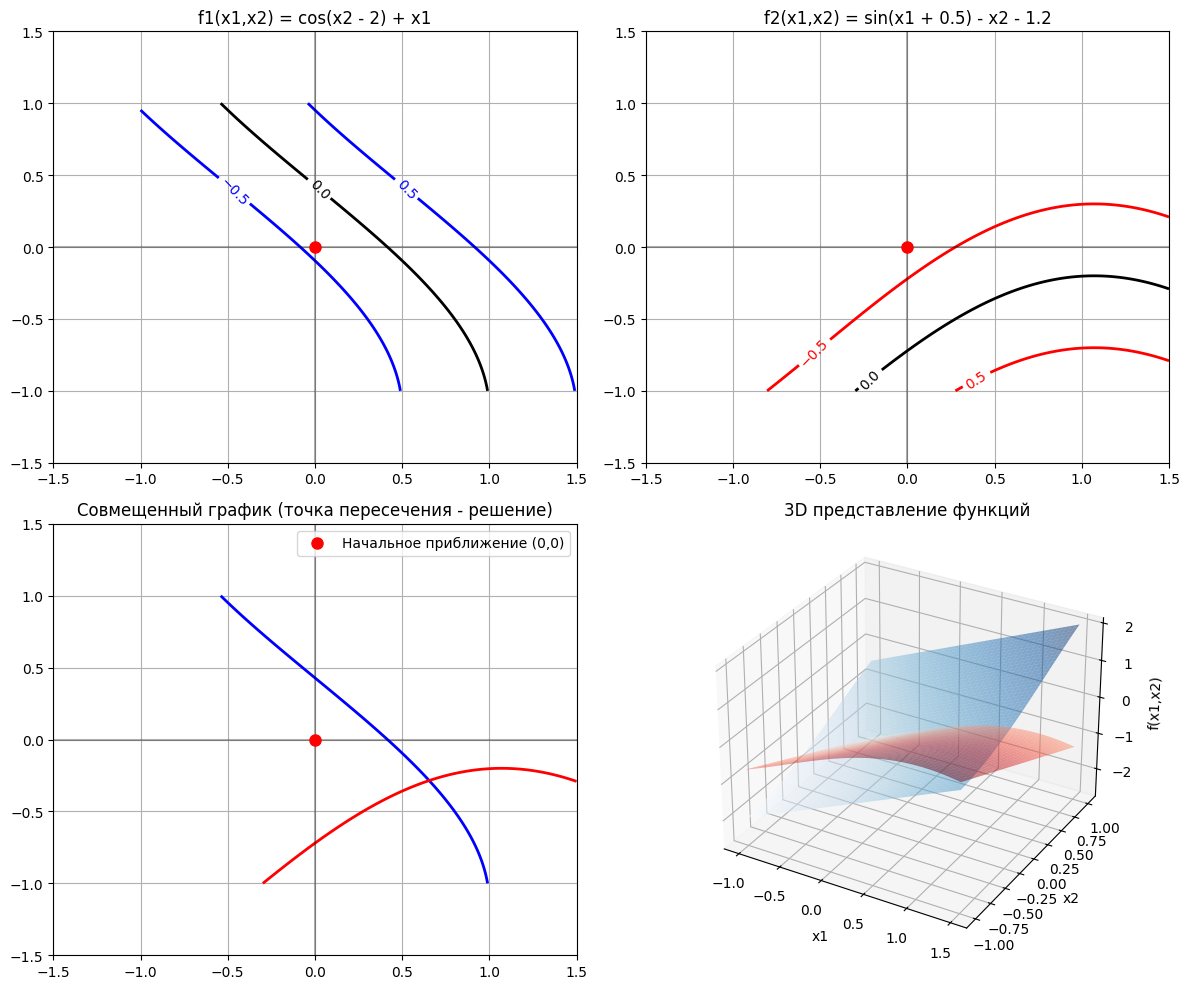


Обоснование выбора начального приближения X = (0, 0):
1. Значение f1(0, 0) = -0.416147
2. Значение f2(0, 0) = -0.720574
3. Определитель матрицы Якоби в точке (0,0): -1.797984
Решение методом Ньютона:
+-----+----------+-----------+-----------------+-----------------+
|   n |     x1^n |      x2^n |   ε_f (невязка) |   ε_x (разница) |
+=====+==========+===========+=================+=================+
|   0 | 0.000000 |  0.000000 |        0.832109 |      inf        |
+-----+----------+-----------+-----------------+-----------------+
|   1 | 0.595869 | -0.197650 |        0.113403 |        0.627794 |
+-----+----------+-----------+-----------------+-----------------+
|   2 | 0.655903 | -0.283222 |        0.002756 |        0.104530 |
+-----+----------+-----------+-----------------+-----------------+
|   3 | 0.655132 | -0.285152 |        0.000001 |        0.002078 |
+-----+----------+-----------+-----------------+-----------------+
|   4 | 0.655131 | -0.285152 |        0.000000 |        0.0000

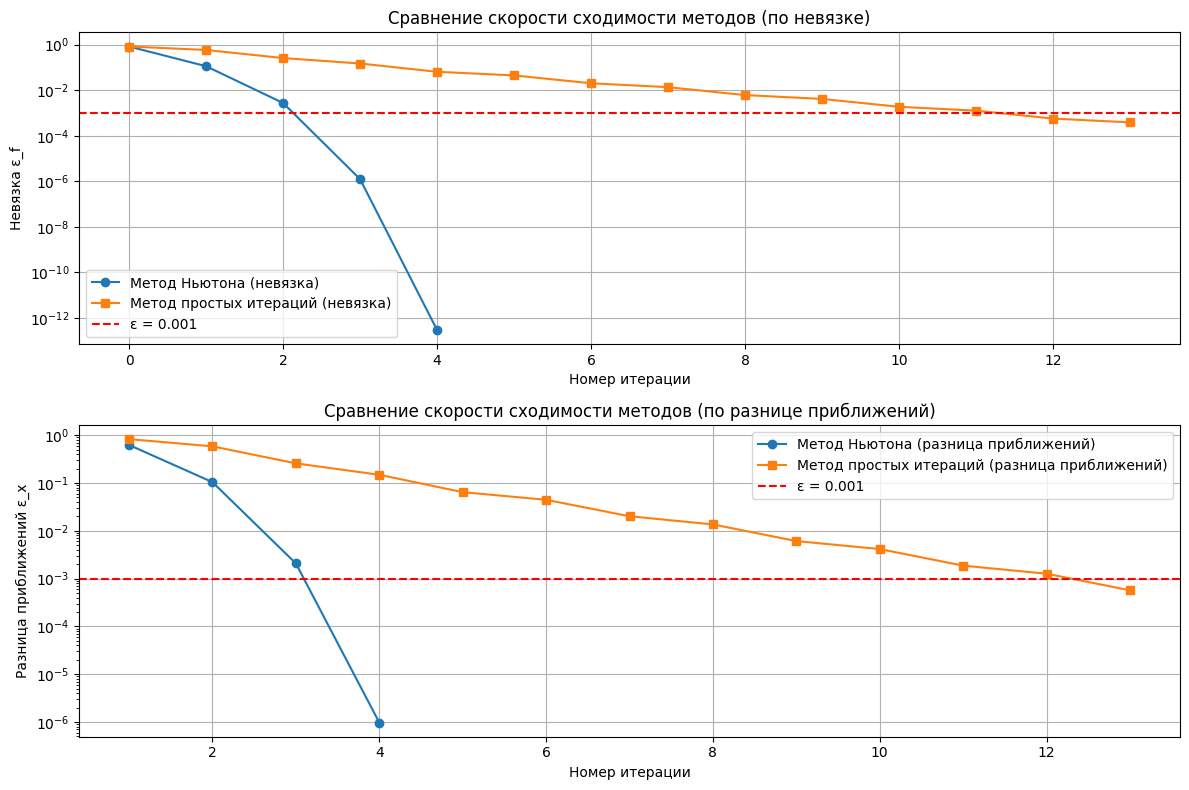


Сравнение методов:
Метод Ньютона: 5 итераций
Метод простых итераций: 14 итераций

Решение методом Ньютона: x1 = 0.655131, x2 = -0.285152
Решение методом простых итераций: x1 = 0.654918, x2 = -0.285358


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

def f1(x1, x2):
    """Первая функция системы: cos(x2 - 2) + x1 = 0"""
    return np.cos(x2 - 2) + x1

def f2(x1, x2):
    """Вторая функция системы: sin(x1 + 0.5) - x2 - 1.2 = 0"""
    return np.sin(x1 + 0.5) - x2 - 1.2

def jacob(x1, x2):
    """Матрица Якоби для системы"""
    j11 = 1
    j12 = -np.sin(x2 - 2)
    j21 = np.cos(x1 + 0.5)
    j22 = -1
    return np.array([[j11, j12], [j21, j22]])

def newton_method(x0, eps=1e-3, max_iter=100):
    """Метод Ньютона для решения системы нелинейных уравнений с дополнительным критерием сходимости"""
    x = np.array(x0, dtype=float)
    iterations = []
    prev_x = None

    for n in range(max_iter):
        # Сохраняем текущее приближение для таблицы
        x1, x2 = x

        # Вычисляем значения функций
        f = np.array([f1(x1, x2), f2(x1, x2)])

        # Вычисляем норму невязки
        error_f = np.linalg.norm(f)

        # Вычисляем разницу между текущим и предыдущим приближением (если возможно)
        error_x = np.inf if prev_x is None else np.linalg.norm(x - prev_x)

        # Сохраняем информацию об итерации
        iterations.append({
            'n': n,
            'x1': x1,
            'x2': x2,
            'error_f': error_f,
            'error_x': error_x
        })

        # Проверяем условие сходимости:
        # 1. Норма невязки должна быть меньше eps
        # 2. Разница между последовательными приближениями должна быть меньше eps
        if error_f < eps and (prev_x is None or error_x < eps):
            break

        # Сохраняем текущее приближение перед обновлением
        prev_x = x.copy()

        # Вычисляем матрицу Якоби
        j = jacob(x1, x2)

        # Решаем СЛАУ для приращения
        try:
            delta = np.linalg.solve(j, -f)
        except np.linalg.LinAlgError:
            print("Невозможно обратить матрицу Якоби")
            break

        # Обновляем приближение
        x = x + delta

    return x, iterations

def simple_iteration_method(x0, eps=1e-3, max_iter=100):
    """Метод простых итераций для решения системы нелинейных уравнений"""
    x = np.array(x0, dtype=float)
    iterations = []

    for n in range(max_iter):
        # Сохраняем текущее приближение
        x1, x2 = x

        # Вычисляем значения функций для проверки невязки
        error_f = np.linalg.norm([f1(x1, x2), f2(x1, x2)])

        # Вычисляем разницу между текущим и предыдущим приближением (если возможно)
        error_x = 0 if n == 0 else np.linalg.norm(x - x_prev)

        # Сохраняем информацию об итерации
        iterations.append({
            'n': n,
            'x1': x1,
            'x2': x2,
            'error_f': error_f,
            'error_x': error_x
        })

        # Проверка сходимости по разнице последовательных приближений
        if n > 0 and error_x < eps:
            break

        # Сохраняем текущее приближение для сравнения
        x_prev = x.copy()

        # Вычисляем новое приближение
        x = np.array([
            -np.cos(x2 - 2),
            np.sin(x1 + 0.5) - 1.2
        ])

    return x, iterations

def print_iterations_table(iterations):
    """Вывод таблицы итераций с обоими критериями сходимости"""
    table = []
    for it in iterations:
        table.append([
            it['n'],
            it['x1'],
            it['x2'],
            it['error_f'],
            it['error_x'] if 'error_x' in it else 'N/A'
        ])

    headers = ['n', 'x1^n', 'x2^n', 'ε_f (невязка)', 'ε_x (разница)']
    print(tabulate(table, headers=headers, tablefmt='grid', floatfmt='.6f'))

def check_solution(x, method_name):
    """Проверка решения"""
    x1, x2 = x
    print(f"\nПроверка решения методом {method_name}:")
    print(f"f1({x1}, {x2}) = {f1(x1, x2)}")
    print(f"f2({x1}, {x2}) = {f2(x1, x2)}")

def plot_convergence(newton_iterations, simple_iterations):
    """Визуализация скорости сходимости методов"""
    newton_errors_f = [it['error_f'] for it in newton_iterations]
    newton_errors_x = [it['error_x'] for it in newton_iterations if it['n'] > 0]
    simple_errors_f = [it['error_f'] for it in simple_iterations]
    simple_errors_x = [it['error_x'] for it in simple_iterations if it['n'] > 0]

    plt.figure(figsize=(12, 8))

    # График невязок функций
    plt.subplot(2, 1, 1)
    plt.semilogy(range(len(newton_errors_f)), newton_errors_f, 'o-', label='Метод Ньютона (невязка)')
    plt.semilogy(range(len(simple_errors_f)), simple_errors_f, 's-', label='Метод простых итераций (невязка)')
    plt.axhline(y=eps, color='r', linestyle='--', label=f'ε = {eps}')
    plt.xlabel('Номер итерации')
    plt.ylabel('Невязка ε_f')
    plt.grid(True)
    plt.legend()
    plt.title('Сравнение скорости сходимости методов (по невязке)')

    # График разницы приближений
    plt.subplot(2, 1, 2)
    plt.semilogy(range(1, len(newton_errors_x) + 1), newton_errors_x, 'o-', label='Метод Ньютона (разница приближений)')
    plt.semilogy(range(1, len(simple_errors_x) + 1), simple_errors_x, 's-', label='Метод простых итераций (разница приближений)')
    plt.axhline(y=eps, color='r', linestyle='--', label=f'ε = {eps}')
    plt.xlabel('Номер итерации')
    plt.ylabel('Разница приближений ε_x')
    plt.grid(True)
    plt.legend()
    plt.title('Сравнение скорости сходимости методов (по разнице приближений)')

    plt.tight_layout()
    plt.savefig('convergence_comparison.png')
    plt.show()

def plot_functions():
    """Визуализация функций системы уравнений"""
    # Создание сетки точек для построения графиков
    x1 = np.linspace(-1, 1.5, 300)
    x2 = np.linspace(-1, 1, 300)
    X1, X2 = np.meshgrid(x1, x2)

    # Вычисление значений функций на сетке
    Z1 = f1(X1, X2)
    Z2 = f2(X1, X2)

    # Создание графика
    plt.figure(figsize=(12, 10))

    # График первой функции: cos(x2 - 2) + x1 = 0
    plt.subplot(2, 2, 1)
    contour1 = plt.contour(X1, X2, Z1, levels=[-0.5, 0, 0.5], colors=['blue', 'black', 'blue'], linewidths=2)
    plt.clabel(contour1, inline=True, fontsize=10)
    plt.title('f1(x1,x2) = cos(x2 - 2) + x1')
    plt.grid(True)
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    plt.plot(0, 0, 'ro', markersize=8)  # Начальное приближение
    plt.xlim(-1.5, 1.5)
    plt.ylim(-1.5, 1.5)

    # График второй функции: sin(x1 + 0.5) - x2 - 1.2 = 0
    plt.subplot(2, 2, 2)
    contour2 = plt.contour(X1, X2, Z2, levels=[-0.5, 0, 0.5], colors=['red', 'black', 'red'], linewidths=2)
    plt.clabel(contour2, inline=True, fontsize=10)
    plt.title('f2(x1,x2) = sin(x1 + 0.5) - x2 - 1.2')
    plt.grid(True)
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    plt.plot(0, 0, 'ro', markersize=8)  # Начальное приближение
    plt.xlim(-1.5, 1.5)
    plt.ylim(-1.5, 1.5)

    # Совмещенный график обеих функций
    plt.subplot(2, 2, 3)
    plt.contour(X1, X2, Z1, levels=[0], colors='blue', linewidths=2, label='f1(x1,x2)=0')
    plt.contour(X1, X2, Z2, levels=[0], colors='red', linewidths=2, label='f2(x1,x2)=0')
    plt.title('Совмещенный график (точка пересечения - решение)')
    plt.grid(True)
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    plt.plot(0, 0, 'ro', markersize=8, label='Начальное приближение (0,0)')
    plt.legend()
    plt.xlim(-1.5, 1.5)
    plt.ylim(-1.5, 1.5)

    # 3D-поверхность для лучшей визуализации
    ax = plt.subplot(2, 2, 4, projection='3d')
    surf1 = ax.plot_surface(X1, X2, Z1, alpha=0.5, cmap='Blues')
    surf2 = ax.plot_surface(X1, X2, Z2, alpha=0.5, cmap='Reds')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_zlabel('f(x1,x2)')
    ax.set_title('3D представление функций')

    plt.tight_layout()
    plt.savefig('functions_visualization.png')
    plt.show()

def explain_initial_approximation():
    """Анализ выбора начального приближения (0,0)"""
    x0 = [0, 0]
    x1, x2 = x0

    # Значения функций в точке (0,0)
    f1_val = f1(x1, x2)
    f2_val = f2(x1, x2)

    # Определитель матрицы Якоби в точке (0,0)
    j = jacob(x1, x2)
    det_j = np.linalg.det(j)

    print("\nОбоснование выбора начального приближения X = (0, 0):")
    print(f"1. Значение f1(0, 0) = {f1_val:.6f}")
    print(f"2. Значение f2(0, 0) = {f2_val:.6f}")
    print(f"3. Определитель матрицы Якоби в точке (0,0): {det_j:.6f}")


# Начальное приближение
x0 = [0, 0]
eps = 1e-3

# Построение графиков функций
plot_functions()

# Обоснование выбора начального приближения
explain_initial_approximation()

# Решение методом Ньютона
print("Решение методом Ньютона:")
newton_solution, newton_iterations = newton_method(x0, eps)
print_iterations_table(newton_iterations)
check_solution(newton_solution, "Ньютона")

# Решение методом простых итераций
print("\nРешение методом простых итераций:")
simple_solution, simple_iterations = simple_iteration_method(x0, eps)
print_iterations_table(simple_iterations)
check_solution(simple_solution, "простых итераций")

# Сравнение скорости сходимости
plot_convergence(newton_iterations, simple_iterations)

# Вывод результатов
print("\nСравнение методов:")
print(f"Метод Ньютона: {len(newton_iterations)} итераций")
print(f"Метод простых итераций: {len(simple_iterations)} итераций")
print(f"\nРешение методом Ньютона: x1 = {newton_solution[0]:.6f}, x2 = {newton_solution[1]:.6f}")
print(f"Решение методом простых итераций: x1 = {simple_solution[0]:.6f}, x2 = {simple_solution[1]:.6f}")